# DATE2 实验 2：静态 Bank 所有权失配

数据源：

- `outputs/DATE2/exp2/static_bank_sweep.csv`
- `outputs/DATE2/exp2/per_stage_best.csv`

基线固定保留15个ACC Bank，另外15个SP Bank静态分给IA、Weight、OA。三类SP数据均至少获得1个Bank，因此每阶段共有$C(14,2)=91$种静态分区。


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
roots=[Path.cwd().resolve(),Path.cwd().resolve().parent]
ROOT=next(p for p in roots if (p/'outputs/DATE2/exp2/static_bank_sweep.csv').exists())
OUT=ROOT/'outputs/DATE2/exp2';FIG=ROOT/'fig/DATE2';FIG.mkdir(parents=True,exist_ok=True)
sweep=pd.read_csv(OUT/'static_bank_sweep.csv');best=pd.read_csv(OUT/'per_stage_best.csv')
assert len(sweep)==23*91 and sweep.layer.nunique()==23
assert sweep.groupby('layer').size().eq(91).all()
assert len(sweep[['ia_banks','weight_banks','oa_banks']].drop_duplicates())==91
assert (sweep.ia_banks+sweep.weight_banks+sweep.oa_banks).eq(15).all()
assert {'hotspot_bank_ratio','idle_bank_ratio','max_bank_pressure'}.issubset(sweep.columns)
calculated=sweep.sort_values(['layer','total_cycles','ia_banks','weight_banks']).groupby('layer',as_index=False).first()
check=calculated[['layer','total_cycles','ia_banks','weight_banks','oa_banks']].merge(best[['layer','total_cycles','ia_banks','weight_banks','oa_banks']],on='layer',suffixes=('_calc','_file'))
for c in ('total_cycles','ia_banks','weight_banks','oa_banks'):assert (check[c+'_calc']==check[c+'_file']).all()
print('Validated:',len(sweep),'sweep rows and',len(best),'per-stage optima')
print('Data files:',OUT/'static_bank_sweep.csv',OUT/'per_stage_best.csv')


Validated: 2093 sweep rows and 23 per-stage optima
Data files: /home/MikeNotFound/code/SCALE-Sim/outputs/DATE2/exp2/static_bank_sweep.csv /home/MikeNotFound/code/SCALE-Sim/outputs/DATE2/exp2/per_stage_best.csv


## 1. 每个阶段的最优 Bank 比例


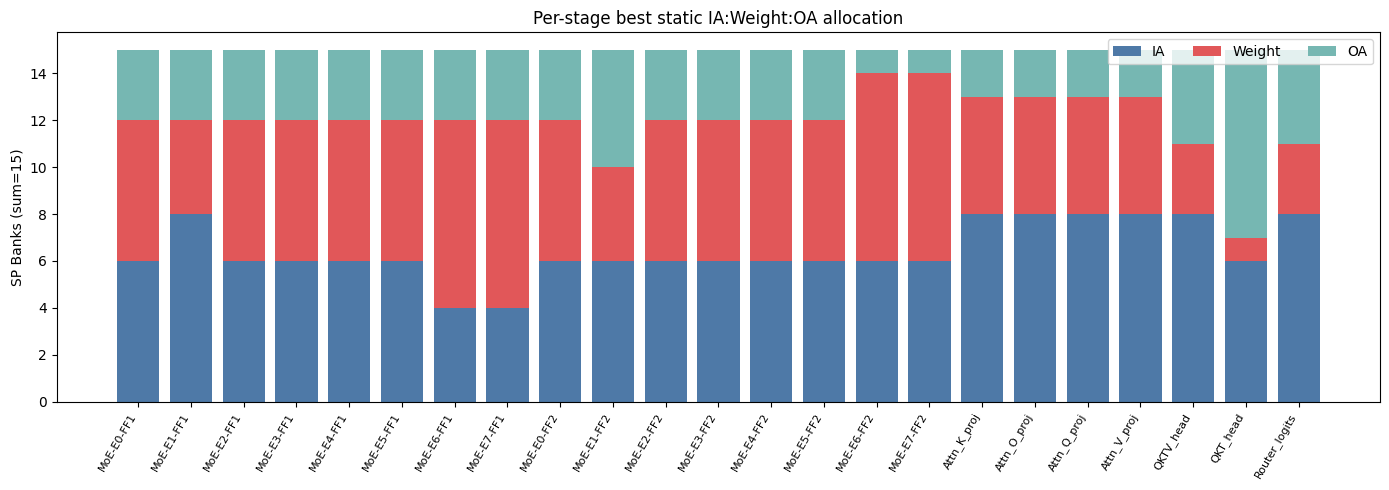

Unique best ratios: 8


ia_banks     weight_banks     oa_banks    
                min max          min max      min max
layer_type                                           
Expert-FF1        4   8            4   8        3   3
Expert-FF2        6   6            4   8        1   5
Non-MoE           6   8            1   5        2   8

In [8]:
ordered=best.sort_values(['layer_type','layer']).reset_index(drop=True);x=np.arange(len(ordered))
fig,ax=plt.subplots(figsize=(14,5));bottom=np.zeros(len(ordered))
for col,label,color in [('ia_banks','IA','#4E79A7'),('weight_banks','Weight','#E15759'),('oa_banks','OA','#76B7B2')]:
    ax.bar(x,ordered[col],bottom=bottom,label=label,color=color);bottom+=ordered[col].to_numpy()
ax.set_xticks(x,ordered.layer,rotation=60,ha='right',fontsize=8);ax.set_ylabel('SP Banks (sum=15)');ax.set_title('Per-stage best static IA:Weight:OA allocation');ax.legend(ncol=3)
plt.tight_layout();plt.savefig(FIG/'exp2_per_stage_best_ratio.pdf',bbox_inches='tight');plt.show()
print('Unique best ratios:',len(best[['ia_banks','weight_banks','oa_banks']].drop_duplicates()))
display(best.groupby('layer_type')[['ia_banks','weight_banks','oa_banks']].agg(['min','max']))


最优比例数量和各类型范围由当前INT8数据动态计算。不存在能代表全部阶段的固定比例。


## 2. 全局固定比例搜索与二维热图


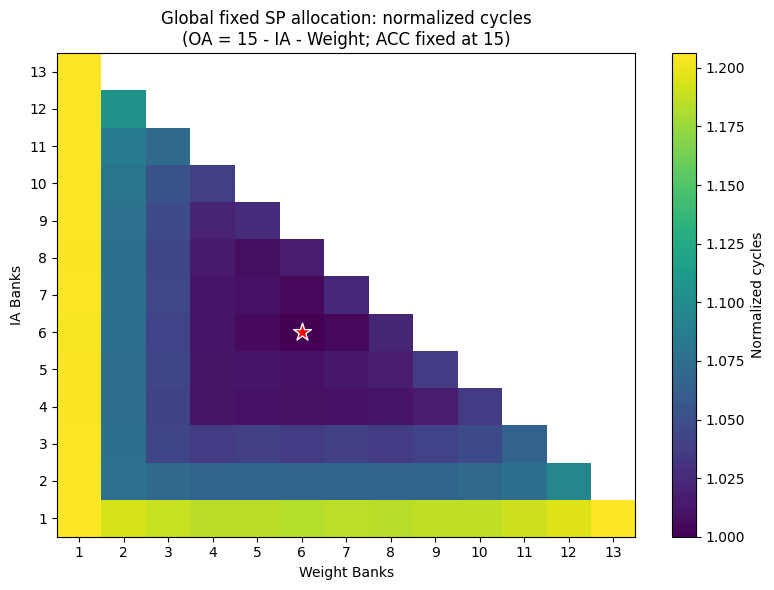

,ia_banks,weight_banks,oa_banks,total_cycles,memory_stall_cycles,bank_conflicts,hotspot_ratio,idle_ratio,normalized_cycles
60,6,6,3,367881,261839,430903,0.301449,0.301449,1.000000
61,6,7,2,369649,263607,428092,0.295652,0.295652,1.004806
68,7,6,2,369649,263607,426322,0.330435,0.330435,1.004806
59,6,5,4,369897,263855,433735,0.324638,0.324638,1.005480
74,8,5,2,370733,264691,424552,0.371014,0.371014,1.007753
41,4,6,5,371436,265394,440287,0.301449,0.301449,1.009663
42,4,7,4,371457,265415,437455,0.281159,0.281159,1.009721
51,5,6,4,371457,265415,435505,0.298551,0.298551,1.009721
40,4,5,6,371595,265553,443140,0.330435,0.330435,1.010096
67,7,5,3,371605,265563,429133,0.342029,0.342029,1.010123


In [9]:
global_result=sweep.groupby(['ia_banks','weight_banks','oa_banks'],as_index=False).agg(total_cycles=('total_cycles','sum'),memory_stall_cycles=('memory_stall_cycles','sum'),bank_conflicts=('bank_conflict_count','sum'),hotspot_ratio=('hotspot_bank_ratio','mean'),idle_ratio=('idle_bank_ratio','mean'))
global_result['normalized_cycles']=global_result.total_cycles/global_result.total_cycles.min()
global_result.to_csv(FIG/'exp2_global_static_summary.csv',index=False)
global_best=global_result.nsmallest(1,'total_cycles').iloc[0]
pivot=global_result.pivot(index='ia_banks',columns='weight_banks',values='normalized_cycles')
fig,ax=plt.subplots(figsize=(8,6));values=pivot.to_numpy();vmax=min(2,float(np.nanpercentile(values,90)));masked=np.ma.masked_invalid(values);im=ax.imshow(masked,origin='lower',aspect='auto',cmap='viridis',vmin=1,vmax=vmax)
ax.set_xticks(range(len(pivot.columns)),pivot.columns);ax.set_yticks(range(len(pivot.index)),pivot.index);ax.set_xlabel('Weight Banks');ax.set_ylabel('IA Banks');ax.set_title('Global fixed SP allocation: normalized cycles\n(OA = 15 - IA - Weight; ACC fixed at 15)');fig.colorbar(im,ax=ax,label='Normalized cycles')
best_x=list(pivot.columns).index(int(global_best.weight_banks));best_y=list(pivot.index).index(int(global_best.ia_banks));ax.scatter(best_x,best_y,marker='*',s=180,color='red',edgecolor='white')
plt.tight_layout();plt.savefig(FIG/'exp2_static_ratio_heatmap.pdf',bbox_inches='tight');plt.show()
global_result.nsmallest(10,'total_cycles')


全工作负载最优固定比例由当前穷举结果确定；旧精度或旧架构下的固定最优比例不能直接移植。


## 3. 代表性固定比例与逐阶段最优下界


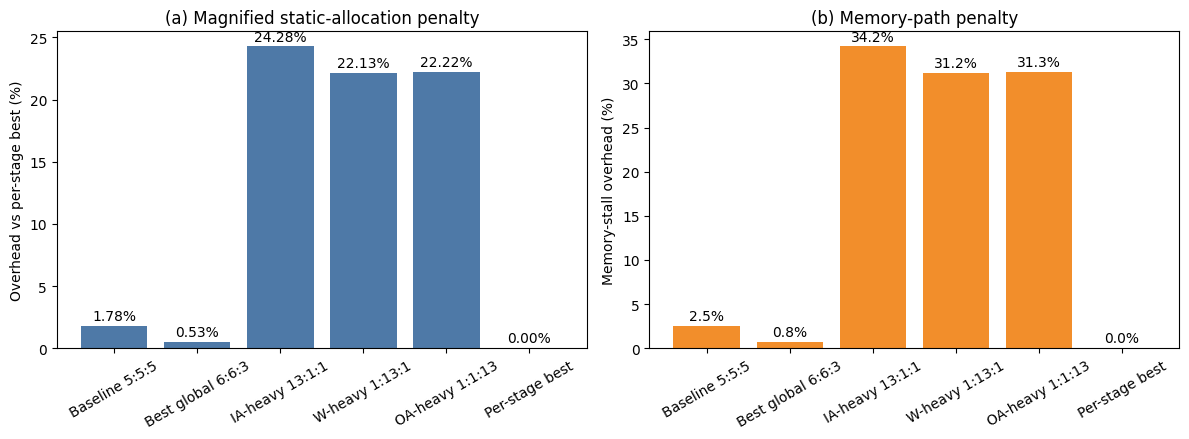

,ratio,total_cycles,memory_stall_cycles,normalized_to_stage_best,overhead_vs_stage_best_pct
0,Baseline 5:5:5,372444.0,266402.0,1.017815,1.781513
1,Best global 6:6:3,367881.0,261839.0,1.005345,0.534536
2,IA-heavy 13:1:1,454770.0,348728.0,1.242796,24.279565
3,W-heavy 1:13:1,446910.0,340868.0,1.221316,22.131584
4,OA-heavy 1:1:13,447230.0,341188.0,1.222190,22.219034
5,Per-stage best,365925.0,259883.0,1.000000,0.000000


Best fixed vs per-stage gap: 0.53%


In [10]:
ratios=[(5,5,5),(int(global_best.ia_banks),int(global_best.weight_banks),int(global_best.oa_banks)),
        (13,1,1),(1,13,1),(1,1,13)]
representative=pd.DataFrame([global_result[(global_result.ia_banks==a)&(global_result.weight_banks==w)&(global_result.oa_banks==o)].iloc[0] for a,w,o in ratios])
representative['ratio']=['Baseline 5:5:5','Best global '+':'.join(map(str,ratios[1])),
                         'IA-heavy 13:1:1','W-heavy 1:13:1','OA-heavy 1:1:13']
stage_lower_bound=int(best.total_cycles.sum());fixed_best=int(global_best.total_cycles)
comparison=pd.concat([representative[['ratio','total_cycles','memory_stall_cycles']],pd.DataFrame([{'ratio':'Per-stage best','total_cycles':stage_lower_bound,'memory_stall_cycles':int(best.memory_stall_cycles.sum())}])],ignore_index=True)
comparison['normalized_to_stage_best']=comparison.total_cycles/stage_lower_bound
comparison['overhead_vs_stage_best_pct']=(comparison.normalized_to_stage_best-1)*100
comparison.to_csv(FIG/'exp2_representative_comparison.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
bars=axes[0].bar(comparison.ratio,comparison.overhead_vs_stage_best_pct,color=['#4E79A7']*5+['#59A14F'])
axes[0].bar_label(bars,fmt='%.2f%%',padding=2);axes[0].tick_params(axis='x',rotation=30)
axes[0].set_ylabel('Overhead vs per-stage best (%)');axes[0].set_title('(a) Magnified static-allocation penalty')
stall_overhead=(comparison.memory_stall_cycles/comparison.memory_stall_cycles.iloc[-1]-1)*100
bars=axes[1].bar(comparison.ratio,stall_overhead,color=['#F28E2B']*5+['#59A14F'])
axes[1].bar_label(bars,fmt='%.1f%%',padding=2);axes[1].tick_params(axis='x',rotation=30)
axes[1].set_ylabel('Memory-stall overhead (%)');axes[1].set_title('(b) Memory-path penalty')
plt.tight_layout();plt.savefig(FIG/'exp2_static_vs_stage_best.pdf',bbox_inches='tight');plt.show();display(comparison)
print(f'Best fixed vs per-stage gap: {(fixed_best/stage_lower_bound-1)*100:.2f}%')


逐阶段分别选择最优比例得到动态切换潜力上界。当前差距由上方表格实时计算，不沿用旧精度结果；该上界不代表零开销动态实现。


## 4. 固定比例对不同阶段的失配


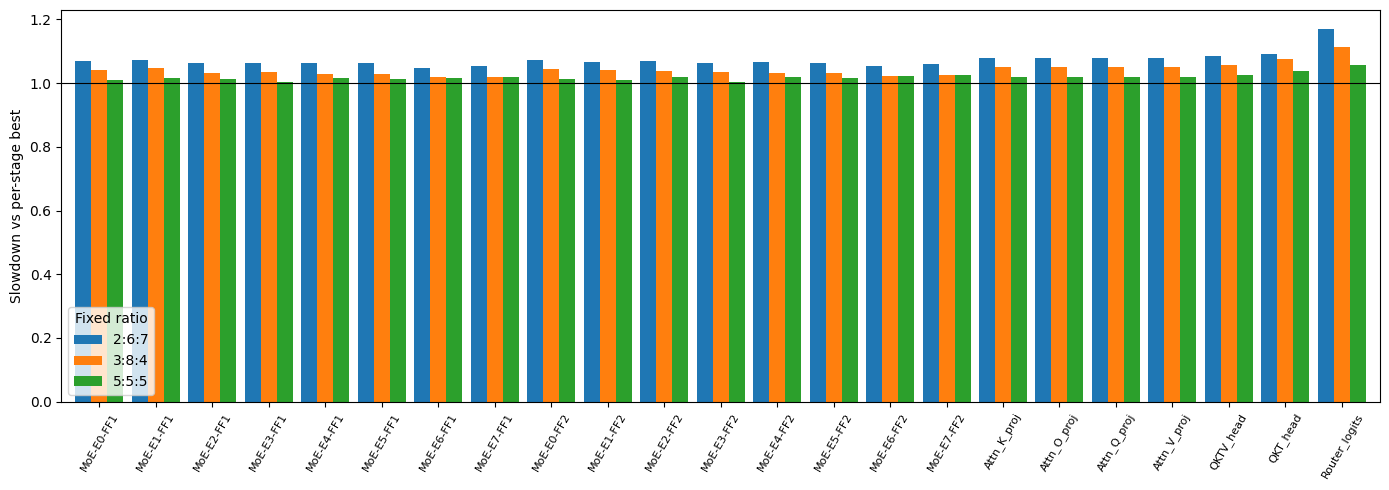

ratio,2:6:7,3:8:4,5:5:5
mean,1.073,1.042,1.019
max,1.171,1.113,1.056


In [11]:
rows=[]
for a,w,o in [(5,5,5),(3,8,4),(2,6,7)]:
    q=sweep[(sweep.ia_banks==a)&(sweep.weight_banks==w)&(sweep.oa_banks==o)].merge(best[['layer','total_cycles']],on='layer',suffixes=('','_best'));q['slowdown']=q.total_cycles/q.total_cycles_best;q['ratio']=f'{a}:{w}:{o}';rows.append(q)
penalty=pd.concat(rows);penalty.to_csv(FIG/'exp2_per_stage_penalty.csv',index=False)
fig,ax=plt.subplots(figsize=(14,5));p=penalty.pivot(index='layer',columns='ratio',values='slowdown').loc[ordered.layer];p.plot(kind='bar',ax=ax,width=.85);ax.axhline(1,color='black',lw=.8);ax.set_ylabel('Slowdown vs per-stage best');ax.set_xlabel('');ax.tick_params(axis='x',rotation=60,labelsize=8);ax.legend(title='Fixed ratio')
plt.tight_layout();plt.savefig(FIG/'exp2_per_stage_slowdown.pdf',bbox_inches='tight');plt.show()
display(p.describe().loc[['mean','max']].round(3))


固定比例的算术平均与最差slowdown由当前表格实时计算。对Weight-heavy Expert有利的比例可能伤害Router或Attention阶段，反之亦然。


## 5. Hotspot、Idle Bank 与所有权压力


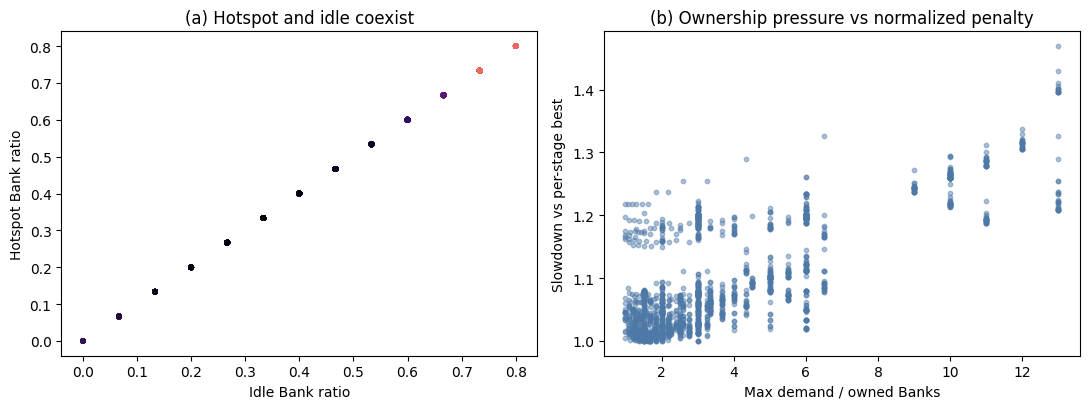

Hotspot nonzero: 98.90%
Idle nonzero: 98.90%
Both: 98.90%
Slowdown/ownership-pressure correlation: 0.7715849648423265
Worst whole-workload fixed-ratio penalty: 23.6%
Worst per-stage fixed-ratio penalty: 46.9%
Best-global ratio worst-stage penalty: 5.7%


In [12]:
both=(sweep.hotspot_bank_ratio>0)&(sweep.idle_bank_ratio>0)
diagnostic=sweep.merge(best[['layer','total_cycles']],on='layer',suffixes=('','_stage_best'))
diagnostic['slowdown']=diagnostic.total_cycles/diagnostic.total_cycles_stage_best
fig,axes=plt.subplots(1,2,figsize=(11,4.2));axes[0].scatter(sweep.idle_bank_ratio,sweep.hotspot_bank_ratio,c=diagnostic.slowdown,s=10,cmap='magma',alpha=.55);axes[0].set_xlabel('Idle Bank ratio');axes[0].set_ylabel('Hotspot Bank ratio');axes[0].set_title('(a) Hotspot and idle coexist')
axes[1].scatter(diagnostic.max_bank_pressure,diagnostic.slowdown,s=10,alpha=.45,color='#4E79A7');axes[1].set_xlabel('Max demand / owned Banks');axes[1].set_ylabel('Slowdown vs per-stage best');axes[1].set_title('(b) Ownership pressure vs normalized penalty')
plt.tight_layout();plt.savefig(FIG/'exp2_bank_pathology.pdf',bbox_inches='tight');plt.show()
print(f'Hotspot nonzero: {(sweep.hotspot_bank_ratio>0).mean():.2%}')
print(f'Idle nonzero: {(sweep.idle_bank_ratio>0).mean():.2%}')
print(f'Both: {both.mean():.2%}')
print('Slowdown/ownership-pressure correlation:',diagnostic.slowdown.corr(diagnostic.max_bank_pressure))
global_worst=global_result.total_cycles.max()/global_result.total_cycles.min()-1
local_worst=diagnostic.slowdown.max()-1
best_global_rows=diagnostic[(diagnostic.ia_banks==int(global_best.ia_banks))&
                            (diagnostic.weight_banks==int(global_best.weight_banks))&
                            (diagnostic.oa_banks==int(global_best.oa_banks))]
print(f'Worst whole-workload fixed-ratio penalty: {global_worst:.1%}')
print(f'Worst per-stage fixed-ratio penalty: {local_worst:.1%}')
print(f'Best-global ratio worst-stage penalty: {(best_global_rows.slowdown.max()-1):.1%}')


Hotspot、idle Bank及其共现比例和slowdown/所有权压力相关性由当前数据动态打印。
这里使用归一化slowdown而不是绝对stall，避免大层天然周期更多造成的伪相关。

## 实验 2 最终判断

- **可以证明**：各阶段最优 Bank 比例显著不同；最优全局固定比例仍落后于逐阶段上界；固定比例会造成局部退化；hotspot 与 idle Bank 能同时出现。
- **理论含义**：动态方案的搜索空间必须包含每层静态 incumbent；这样静态恰好最优时动态可选择同一映射，静态失配时才切换到更优映射。实验 2 给出这种逐层选择的优化空间，逐层 dominance 契约由实验 4 的报告核验。
- **不能直接证明**：动态架构一定获得完整上界收益。该上界没有包含映射查询、分配和切换开销，必须由exp4的真实动态及跨模型消融结果验证。
- **精度与资源契约**：IA/Weight/OA为INT8；ACC为banked INT32 RMW；总资源为15 SP + 15 ACC。
